In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import scipy.io as sio
from PIL import Image
import numpy as np
import torch.nn.functional as F

c:\Users\enine\anaconda3\envs\changhl\Lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: '[WinError 127] 找不到指定的程序。'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
# --------------------- 数据集 ---------------------
class MultiModalDataset(Dataset):
    def __init__(self, image_paths, nir_data, labels, transform=None):
        self.image_paths = image_paths
        self.nir_data = nir_data
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx][0]  # 这里是路径
        img = Image.open(img_path).convert('RGB')  # 正确打开图片！

        if self.transform:
            img = self.transform(img)  # 对PIL Image应用transform
        
        nir = torch.tensor(self.nir_data[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        
        return img, nir, label

In [3]:
# --------------------- 图像特征提取器（金字塔） ---------------------
class PyramidCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        
        # === 添加多尺度特征输出 ===
        self.multi_scale = nn.ModuleList([
            nn.Sequential(
                nn.AdaptiveAvgPool2d((1,1)),
                nn.Flatten()
            ) for _ in [64, 32, 16]  # 不同尺度的池化
        ])
        self.scale_proj = nn.Linear(128*3, 128)  # 多尺度特征投影

    def forward(self, x):
        x1 = self.layer1(x)  # 第一层特征
        x2 = self.layer2(x1)  # 第二层特征
        x3 = self.layer3(x2)  # 第三层特征
        
        # === 多尺度特征提取 ===
        features = []
        for i, pool in enumerate(self.multi_scale):
            size = [64, 32, 16][i]
            resized = F.interpolate(x3, size=(size, size)) if size != x3.shape[-1] else x3
            features.append(pool(resized))
        
        # 拼接多尺度特征
        multi_feat = torch.cat(features, dim=1)
        return self.scale_proj(multi_feat)  # 投影到统一维度


# --------------------- NIR特征提取器（A-CNN + A-GRU） ---------------------
class NIRAttentionExtractor(nn.Module):
    def __init__(self):
        super(NIRAttentionExtractor, self).__init__()
        
        # 改进的A-CNN
        self.conv = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(64)  # 统一输出长度
        )
        
        # 改进的SE block
        self.se_block = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(64, 64),  # 减少压缩比例
            nn.SiLU(),  # 更平滑的激活
            nn.Linear(64, 64),
            nn.Sigmoid()
        )
        
        # 改进的A-GRU
        self.pre_gru = nn.Linear(128, 64)  # 前置特征提取
        self.gru = nn.GRU(input_size=64, hidden_size=64, batch_first=True, bidirectional=True)
        
        # 改进的注意力
        self.attn_fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        
        # 修正的特征融合层
        # 输入应该是CNN(64) + GRU(128) = 192
        # 输出保持192维或调整为其他统一维度
        self.fusion = nn.Linear(192, 192)  # 输入输出都设为192

    def forward(self, x):
        # A-CNN
        x_cnn = x.unsqueeze(1)  # (batch_size, 1, 128)
        x_cnn = self.conv(x_cnn)  # (batch_size, 64, 64)
        se = self.se_block(x_cnn).unsqueeze(-1)  # (batch_size, 64, 1)
        x_cnn = x_cnn * se  # SE加权
        x_cnn = x_cnn.mean(dim=-1)  # (batch_size, 64)
        
        # A-GRU
        x_gru = self.pre_gru(x)  # (batch_size, 64)
        x_gru = x_gru.unsqueeze(1)  # (batch_size, 1, 64)
        x_gru, _ = self.gru(x_gru)  # (batch_size, 1, 128)
        
        # 改进的注意力计算
        attn_weights = torch.softmax(self.attn_fc(x_gru), dim=1)  # (batch_size, 1, 1)
        x_gru = torch.sum(x_gru * attn_weights, dim=1)  # (batch_size, 128)
        
        # 特征融合
        features = torch.cat([x_cnn, x_gru], dim=1)  # (batch_size, 192)
        features = self.fusion(features)  # (batch_size, 192) 带权重
        
        return features

# --------------------- 蒸馏三分类模型 ---------------------
class CrossModalFusion(nn.Module):
    def __init__(self, img_dim=128, nir_dim=192, hidden_dim=256):
        super().__init__()
        
        # 可学习的模态权重（图像 vs NIR）
        self.importance = nn.Parameter(torch.ones(2))  # 初始化为均等权重
        
        # 模态特征投影
        self.img_proj = nn.Sequential(
            nn.Linear(img_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU()
        )
        self.nir_proj = nn.Sequential(
            nn.Linear(nir_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU()
        )
        
        # 跨模态注意力
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim*2, hidden_dim//2),
            nn.ReLU(),
            nn.Linear(hidden_dim//2, 2),  # 输出两个模态的注意力权重
            nn.Softmax(dim=1)
        )
        
        # 融合层
        self.fusion = nn.Linear(hidden_dim*2, hidden_dim, device='cuda:0')  # 直接在GPU上创建

    def forward(self, img_feat, nir_feat):
        # 计算模态重要性权重（全局可学习参数）
        modal_weights = torch.softmax(self.importance, dim=0)
        
        # 加权特征投影
        img_proj = self.img_proj(img_feat * modal_weights[0])
        nir_proj = self.nir_proj(nir_feat * modal_weights[1])
        
        # 跨模态注意力（动态调整）
        attn_weights = self.attention(torch.cat([img_proj, nir_proj], dim=1))
        
        # 加权融合
        fused = torch.cat([
            img_proj * attn_weights[:, 0:1],
            nir_proj * attn_weights[:, 1:2]
        ], dim=1)
        
        return self.fusion(fused)

class MultiModalNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        
        # 特征提取器
        self.image_encoder = PyramidCNN()  # 输出128维
        self.nir_encoder = NIRAttentionExtractor()  # 输出192维
        
        # 自适应特征融合
        self.fusion = CrossModalFusion()  # 输出256维
        
        # 对比学习投影头
        self.projection_head = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64, affine=False)  # 对比学习最后一层通常不加affine
        )
        
        # 分类头
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, img, nir, mode='train'):
        # 特征提取
        img_feat = self.image_encoder(img)  # (B,128)
        nir_feat = self.nir_encoder(nir)   # (B,192)
        
        # 自适应融合
        fused = self.fusion(img_feat, nir_feat)  # (B,256)
        
        # 模式选择
        if mode == 'pretrain': 
            print("Pretrain mode activated")
            return F.normalize(self.projection_head(fused), p=2, dim=1)  # 单位向量,    
        else:
            return self.classifier(fused)

Epoch 1: Train Loss = 1.1484, Train Acc = 0.3917, Val Acc = 0.2667
Best model updated at epoch 1
Epoch 2: Train Loss = 0.9254, Train Acc = 0.5500, Val Acc = 0.2667
Epoch 3: Train Loss = 0.8805, Train Acc = 0.6583, Val Acc = 0.2667
Epoch 4: Train Loss = 0.7830, Train Acc = 0.6917, Val Acc = 0.2667
Epoch 5: Train Loss = 0.7640, Train Acc = 0.7000, Val Acc = 0.2667
Epoch 6: Train Loss = 0.6538, Train Acc = 0.8000, Val Acc = 0.2667
Epoch 7: Train Loss = 0.5469, Train Acc = 0.8250, Val Acc = 0.2667
Epoch 8: Train Loss = 0.5705, Train Acc = 0.8667, Val Acc = 0.2667
Epoch 9: Train Loss = 0.5573, Train Acc = 0.8750, Val Acc = 0.2667
Epoch 10: Train Loss = 0.4554, Train Acc = 0.9000, Val Acc = 0.2667
Epoch 11: Train Loss = 0.4478, Train Acc = 0.9000, Val Acc = 0.2667
Epoch 12: Train Loss = 0.4494, Train Acc = 0.8750, Val Acc = 0.2667
Epoch 13: Train Loss = 0.4822, Train Acc = 0.8417, Val Acc = 0.2667
Epoch 14: Train Loss = 0.3745, Train Acc = 0.9083, Val Acc = 0.2667
Epoch 15: Train Loss = 0.39

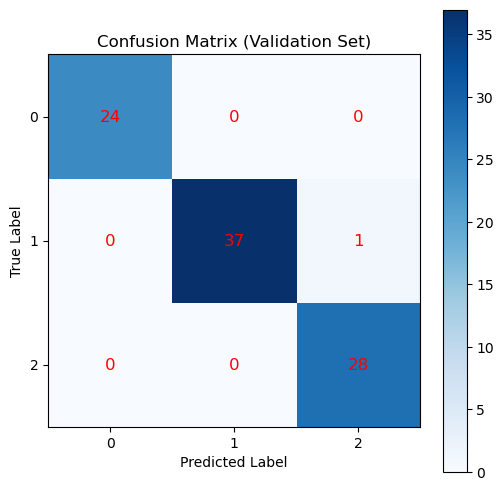

C:\Users\enine\AppData\Local\Temp\ipykernel_33436\349950317.py:153: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth"))


Best Model Test Accuracy: 0.9111111111111111


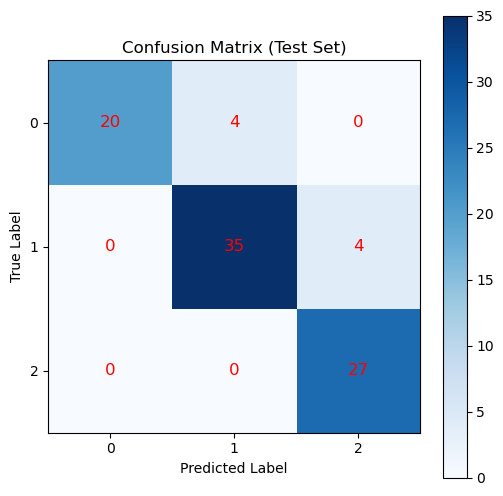

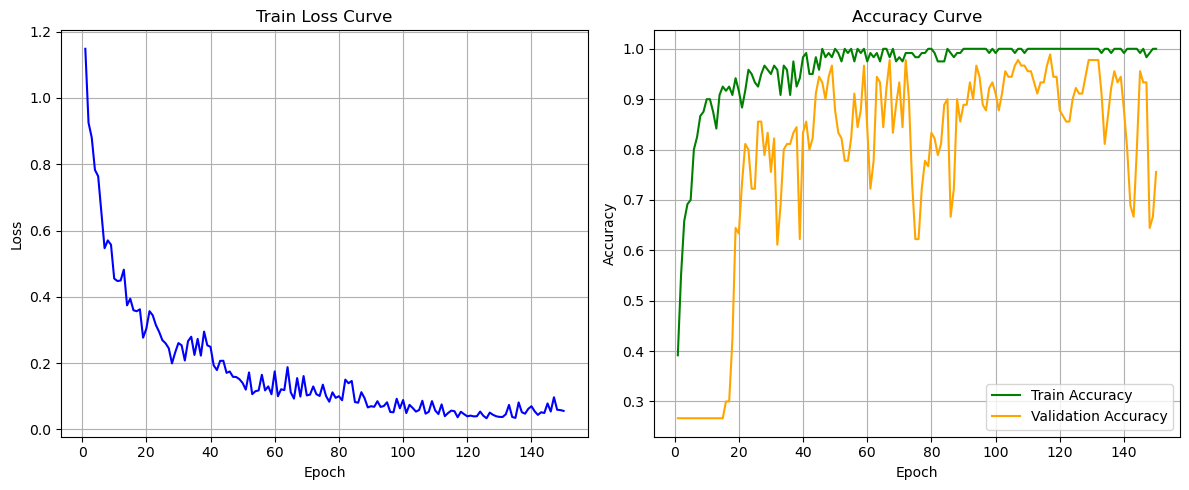

In [4]:
# --------------------- 主程序 ---------------------
# 加载数据
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# 训练集的数据增强
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
])

# 验证集和测试集，只做基本处理
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
image_dataset = ImageFolder(root=r"L:\\常惠林\\萎凋\\所有样本", transform=transform)
nir_mat = sio.loadmat(r"L:\\常惠林\\萎凋\\NIR.mat")
nir_data = nir_mat['nir']  # (300, 128)

# 数据划分
# 划分训练集（40%）和临时集（60%）
train_idx, temp_idx = train_test_split(
    range(300),
    test_size=0.6,  # 留60%给验证+测试
    stratify=image_dataset.targets,  # 分层抽样，保持类别比例
    random_state=42
)

# 划分验证集（20%）和测试集（40%）
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,  
    stratify=[image_dataset.targets[i] for i in temp_idx],  # 保持类别比例一致
    random_state=42
)

def subset(dataset, idxs):
    imgs = [dataset.imgs[i] for i in idxs]
    targets = [dataset.targets[i] for i in idxs]
    return imgs, targets

train_imgs, train_labels = subset(image_dataset, train_idx)
val_imgs, val_labels = subset(image_dataset, val_idx)
test_imgs, test_labels = subset(image_dataset, test_idx)

# 注意，分别赋不同的transform！
train_dataset = MultiModalDataset(train_imgs, nir_data[train_idx], train_labels, transform=train_transform)
val_dataset = MultiModalDataset(val_imgs, nir_data[val_idx], val_labels, transform=val_test_transform)
test_dataset = MultiModalDataset(test_imgs, nir_data[test_idx], test_labels, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=48, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=48)
test_loader = DataLoader(test_dataset, batch_size=48)

# 初始化模型
model = MultiModalNet().cuda()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 添加容器来存储loss和准确率
train_losses = []
train_accuracies = []
val_accuracies = []

# ------------------ 训练 ------------------

best_acc = 0
for epoch in range(150):
    model.train()
    epoch_loss = 0
    correct_preds = 0
    total_preds = 0
    
    for imgs, nirs, labels in train_loader:
        imgs, nirs, labels = imgs.cuda(), nirs.cuda(), labels.cuda()
        optimizer.zero_grad()
        
        outputs = model(imgs, nirs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        # 记录训练loss
        epoch_loss += loss.item()
        
        # 计算训练准确率
        preds = outputs.argmax(dim=1)
        correct_preds += (preds == labels).sum().item()
        total_preds += labels.size(0)
    
    # 计算每个epoch的平均loss和准确率
    avg_train_loss = epoch_loss / len(train_loader)
    train_acc = correct_preds / total_preds
    
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)
    
    # 每轮结束后验证
    model.eval()
    preds_val, trues_val = [], []
    with torch.no_grad():
        for imgs, nirs, labels in val_loader:
            imgs, nirs = imgs.cuda(), nirs.cuda()
            outputs = model(imgs, nirs)
            preds_val.extend(outputs.argmax(dim=1).cpu().numpy())
            trues_val.extend(labels.numpy())
    
    val_acc = accuracy_score(trues_val, preds_val)
    val_accuracies.append(val_acc)
    
    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Train Acc = {train_acc:.4f}, Val Acc = {val_acc:.4f}")
    
    # 保存验证集上效果最好的模型及其在验证集的预测
    if val_acc > best_acc:
        best_acc = val_acc
        best_val_preds = preds_val.copy()
        best_val_trues = trues_val.copy()
        torch.save(model.state_dict(), "best_model.pth")
        print(f"Best model updated at epoch {epoch+1}")

# ------------------ 验证集混淆矩阵（best model） ------------------
cm_val = confusion_matrix(best_val_trues, best_val_preds)
val_acc = accuracy_score(best_val_trues, best_val_preds)

print("Best Model Validation Accuracy:", val_acc)

plt.figure(figsize=(6, 6))
plt.imshow(cm_val, cmap='Blues')
plt.title('Confusion Matrix (Validation Set)')
plt.colorbar()

classes = np.arange(cm_val.shape[0])

for i in range(cm_val.shape[0]):
    for j in range(cm_val.shape[1]):
        plt.text(j, i, str(cm_val[i, j]), ha='center', va='center', color='red', fontsize=12)

plt.xticks(classes)
plt.yticks(classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ------------------ 测试集混淆矩阵（best model） ------------------
# 加载最佳模型
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

preds_test, trues_test = [], []
with torch.no_grad():
    for imgs, nirs, labels in test_loader:
        imgs, nirs = imgs.cuda(), nirs.cuda()
        outputs = model(imgs, nirs)
        preds_test.extend(outputs.argmax(dim=1).cpu().numpy())
        trues_test.extend(labels.numpy())

cm_test = confusion_matrix(trues_test, preds_test)
test_acc = accuracy_score(trues_test, preds_test)

print("Best Model Test Accuracy:", test_acc)

plt.figure(figsize=(6, 6))
plt.imshow(cm_test, cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.colorbar()

classes = np.arange(cm_test.shape[0])

for i in range(cm_test.shape[0]):
    for j in range(cm_test.shape[1]):
        plt.text(j, i, str(cm_test[i, j]), ha='center', va='center', color='red', fontsize=12)

plt.xticks(classes)
plt.yticks(classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ------------------ 绘制训练损失和准确率曲线 ------------------
# 绘制训练过程中的损失和准确率
plt.figure(figsize=(12, 5))

# 绘制训练损失曲线
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss", color='blue')
plt.title("Train Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

# 绘制训练和验证准确率曲线
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label="Train Accuracy", color='green')
plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, label="Validation Accuracy", color='orange')
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()